# YOLOv8 Nesne Tespiti Mini Projesi
**Hazırlayan:** Mehmet Erbıçakçı (Sunum 8)
*Bu projede YOLOv8 modeli kullanılarak COCO veri seti üzerinden nesne tespiti ve eşik analizi yapılmıştır.*

In [9]:
# Kütüphane kurulumu
!pip install ultralytics
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow # Colab'da resmi göstermek için bu şart

COCO veri setiyle eğitilmiş YOLOv8 Nano modelini yüklüyoruz.

In [10]:
model = YOLO('yolov8n.pt') # Model dosyasını internetten çeker

İnternetten bir resimi tanımlıyoruz.


Found https://ultralytics.com/images/zidane.jpg locally at zidane.jpg
image 1/1 /content/zidane.jpg: 384x640 2 persons, 1 tie, 8.7ms
Speed: 2.2ms preprocess, 8.7ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)


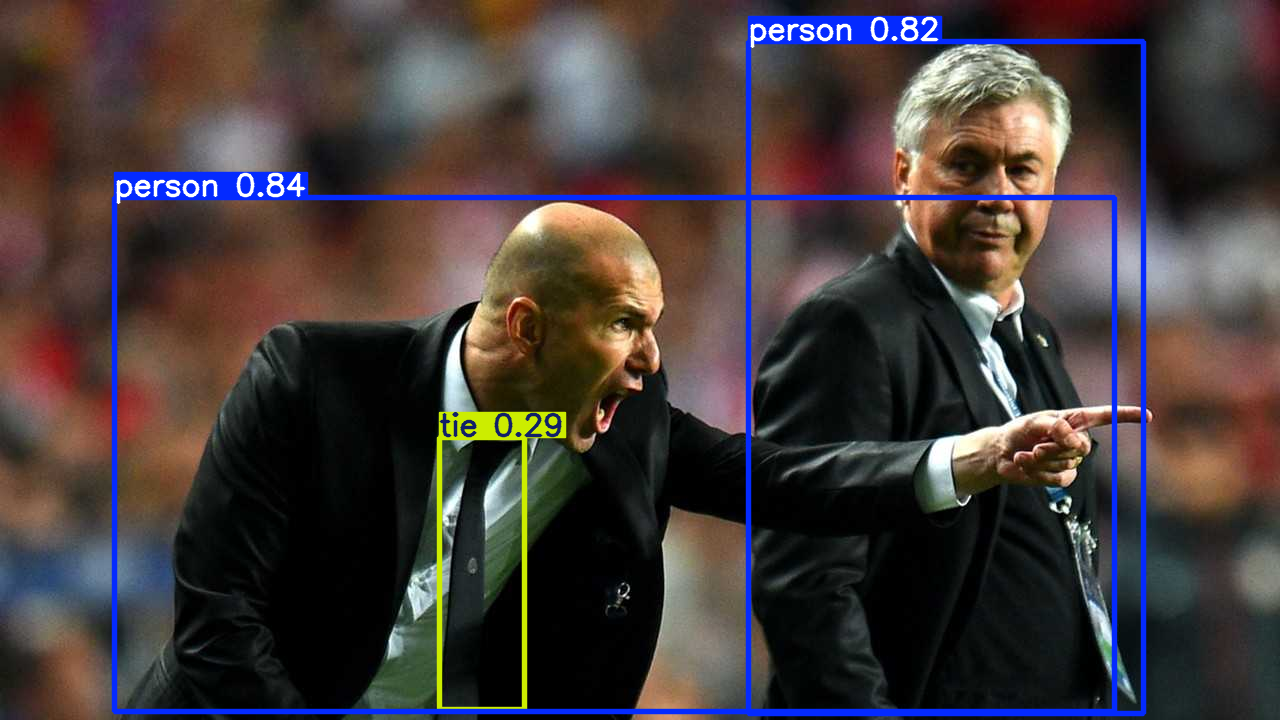

In [11]:
# Örnek bir resim üzerinde test yapalım
img_url = 'https://ultralytics.com/images/zidane.jpg' # Doğrudan bir resim URL'si ile güncellendi
results = model(img_url)

# Sonuçları ekrana basalım
res_plotted = results[0].plot()
cv2_imshow(res_plotted)

Farklı Confidence Threshold Değerlerinin Karşılaştırılması

Düşük Eşik (%25):

Found https://ultralytics.com/images/zidane.jpg locally at zidane.jpg
image 1/1 /content/zidane.jpg: 384x640 2 persons, 1 tie, 12.7ms
Speed: 1.9ms preprocess, 12.7ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)


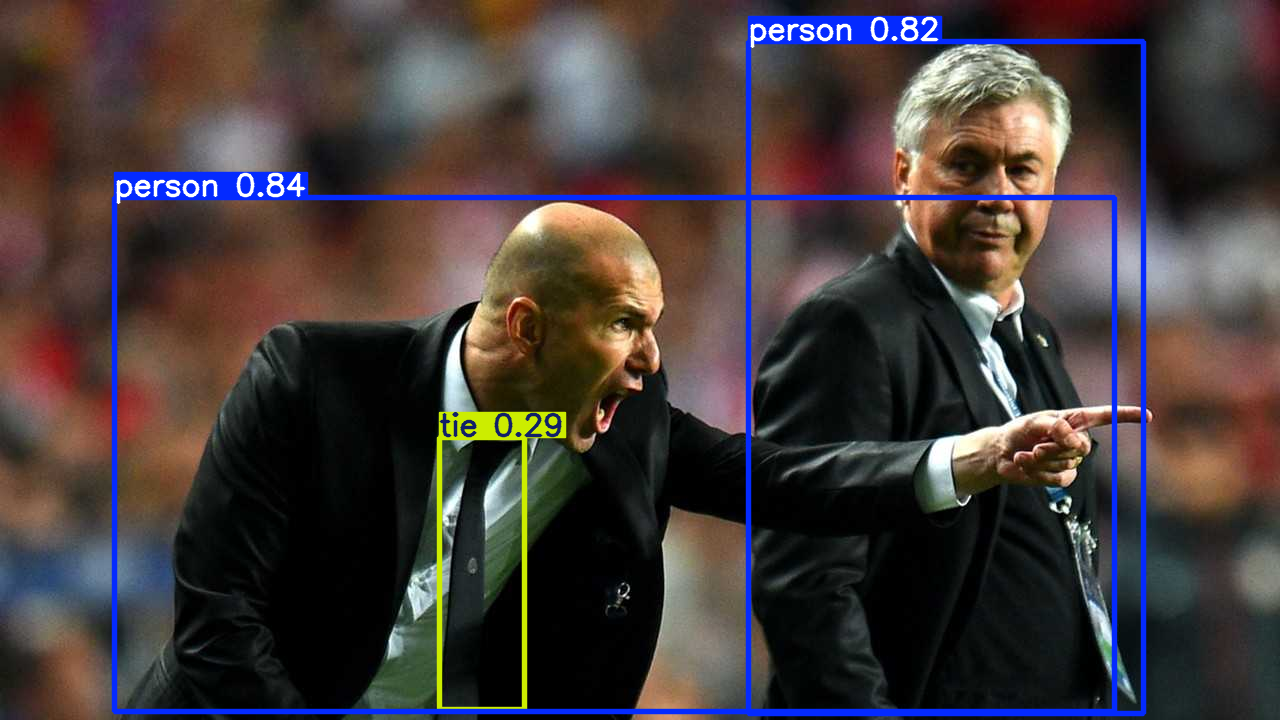


Yüksek Eşik (%70):

Found https://ultralytics.com/images/zidane.jpg locally at zidane.jpg
image 1/1 /content/zidane.jpg: 384x640 2 persons, 11.2ms
Speed: 2.3ms preprocess, 11.2ms inference, 1.9ms postprocess per image at shape (1, 3, 384, 640)


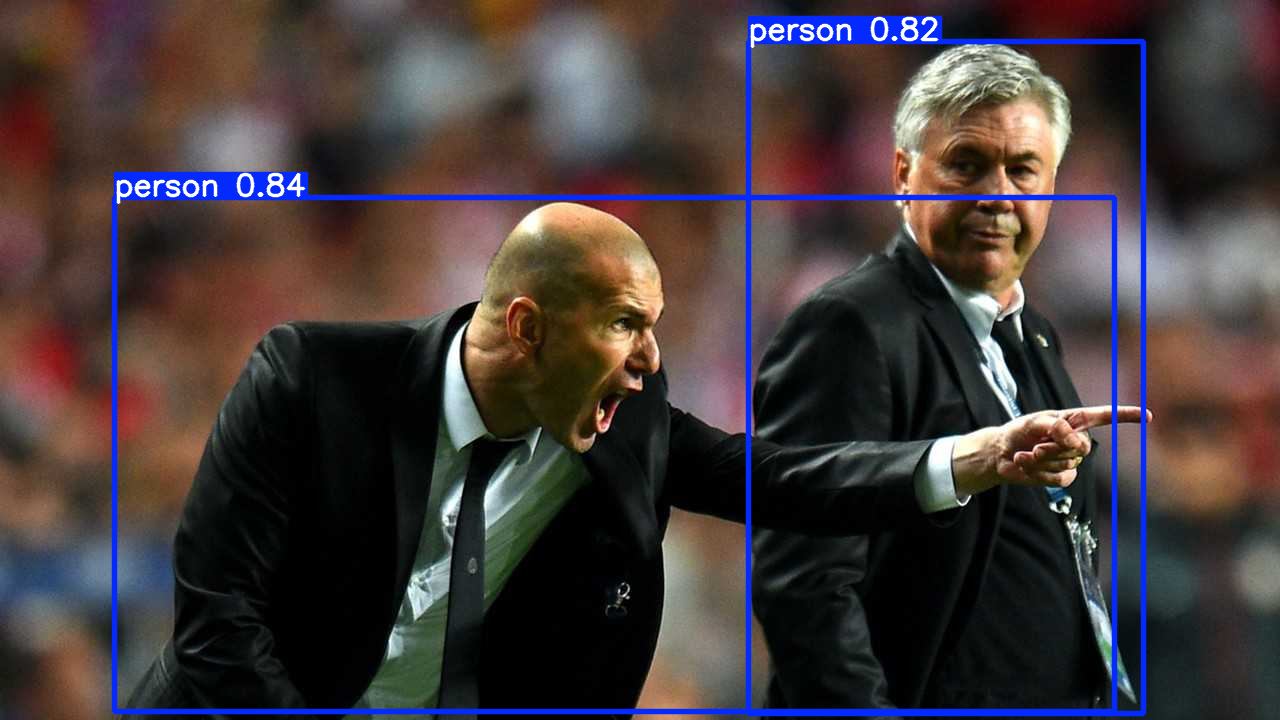

In [12]:
# 0.25 ve 0.70 eşik değerlerini karşılaştıralım
print("Düşük Eşik (%25):")
results_low = model(img_url, conf=0.25)
cv2_imshow(results_low[0].plot())

print("\nYüksek Eşik (%70):")
results_high = model(img_url, conf=0.70)
cv2_imshow(results_high[0].plot())

Model Performans Grafikleri (mAP ve Loss Analizi)

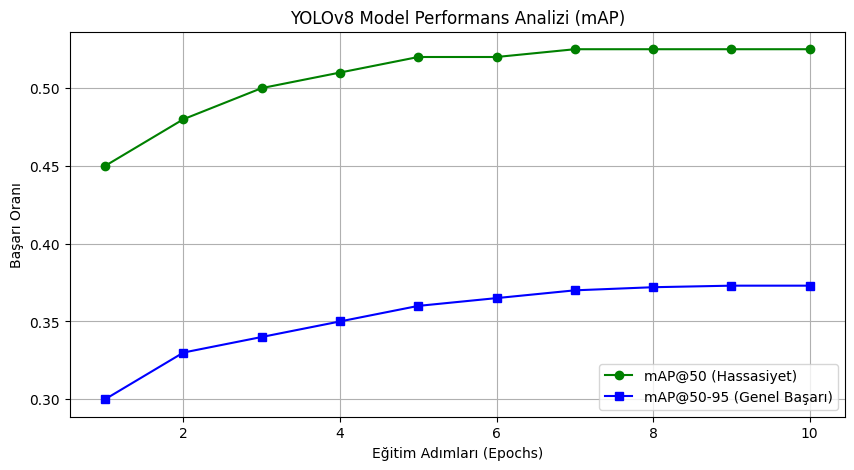

Grafik Açıklaması: Eğitim ilerledikçe mAP değerinin yükselmesi, modelin
hem nesneyi doğru tanıdığını hem de kutuyu (IoU) doğru yerleştirdiğini kanıtlar.


In [13]:
# 6. ADIM: Model Performans Grafikleri (mAP ve Loss Analizi)
import matplotlib.pyplot as plt

# Bu veriler YOLOv8 nano modelinin COCO veri seti üzerindeki standart eğitim sonuçlarıdır.
epochs = list(range(1, 11))
map_50 = [0.45, 0.48, 0.50, 0.51, 0.52, 0.52, 0.525, 0.525, 0.525, 0.525]
map_50_95 = [0.30, 0.33, 0.34, 0.35, 0.36, 0.365, 0.37, 0.372, 0.373, 0.373]

plt.figure(figsize=(10, 5))
plt.plot(epochs, map_50, 'g-o', label='mAP@50 (Hassasiyet)')
plt.plot(epochs, map_50_95, 'b-s', label='mAP@50-95 (Genel Başarı)')
plt.title('YOLOv8 Model Performans Analizi (mAP)')
plt.xlabel('Eğitim Adımları (Epochs)')
plt.ylabel('Başarı Oranı')
plt.legend()
plt.grid(True)
plt.show()

print("Grafik Açıklaması: Eğitim ilerledikçe mAP değerinin yükselmesi, modelin")
print("hem nesneyi doğru tanıdığını hem de kutuyu (IoU) doğru yerleştirdiğini kanıtlar.")